# 🌿 AGRONA — Two-Stage Pipeline (domain-aware)

**Stage 1:** independent Leaf / Not-Leaf gate → rejects non-leaf images.
**Stage 2:** disease classifier (disease classes only). Trained two ways to **solve the lab→field domain gap**:
- *Baseline:* ImageNet → PlantDoc (field data)
- *Improved:* ImageNet → **PlantVillage** → fine-tune on **PlantDoc**

Run on Colab GPU (`Runtime → Change runtime type → GPU`). Have `kaggle.json` ready.
```
This notebook presents AGRONA, a two-stage computer vision system developed by:

Dana Mubarak Al-Anizi
Sama Walid Alharbi
Fatima Fahad Alhiri
Lujain Abdullah Alsulami
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/AGRONA2"
os.makedirs(PROJECT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1) Install
!pip install -q timm scikit-learn matplotlib

In [ ]:
# 2) Imports + seed + device
import os, json, time, random, shutil, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import timm
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
assert device.type=='cuda', 'Switch Runtime to GPU.'


device: cuda


In [ ]:
# 3) Download data
from google.colab import files
print('Upload kaggle.json:'); files.upload()
!mkdir -p ~/.kaggle && mv -f kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# PlantVillage (big, for domain-bridge pretrain) + ImageNet-mini (not-leaf negatives)
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection -p /content -q
!unzip -q -o /content/plant-disease-detection.zip -d /content/plantvillage
!kaggle datasets download -d ifigotin/imagenetmini-1000 -p /content -q
!unzip -q -o /content/imagenetmini-1000.zip -d /content/imagenet_noise
# PlantDoc (real field images) via git clone
!git clone -q https://github.com/pratikkayal/PlantDoc-Dataset /content/plantdoc
print('downloaded')

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection
License(s): MIT
Dataset URL: https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000
License(s): unknown
downloaded


In [ ]:
# 4) Locate dataset roots + mount Drive for artifacts
def find_root(base):
    best,bn=None,0
    for root,dirs,_ in os.walk(base):
        n=0
        for d in dirs:
            p=os.path.join(root,d)
            try:
                if any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in os.listdir(p)): n+=1
            except Exception: pass
        if n>bn: best,bn=root,n
    return best,bn
PV_DIR,_=find_root('/content/plantvillage')
NEG_SRC,_=find_root('/content/imagenet_noise')
PD_TRAIN='/content/plantdoc/train'; PD_TEST='/content/plantdoc/test'
print('PlantVillage:', PV_DIR)
print('Negatives   :', NEG_SRC)
print('PlantDoc train classes:', len(os.listdir(PD_TRAIN)), '| test classes:', len(os.listdir(PD_TEST)))

ARTIFACTS='/content/artifacts'
try:
    from google.colab import drive; drive.mount('/content/drive')
    ARTIFACTS='/content/drive/MyDrive/AGRONA2/artifacts'
except Exception as e: print('Drive not mounted:', e)
os.makedirs(ARTIFACTS, exist_ok=True); print('Artifacts ->', ARTIFACTS)

PlantVillage: /content/plantvillage/Dataset
Negatives   : /content/imagenet_noise/imagenet-mini/val
PlantDoc train classes: 28 | test classes: 27
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts -> /content/drive/MyDrive/AGRONA2/artifacts


In [ ]:
# 5) Transforms + shared helpers
MEAN,STD=[0.485,0.456,0.406],[0.229,0.224,0.225]
train_tf=transforms.Compose([transforms.RandomResizedCrop(224,scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30), transforms.ColorJitter(0.3,0.3,0.3),
    transforms.GaussianBlur(3,(0.1,1.5)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_tf=transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

def build_model(num_classes, pretrained=True, dropout=0.4):
    m=timm.create_model('mobilenetv2_100', pretrained=pretrained, num_classes=num_classes)
    inf=m.classifier.in_features
    m.classifier=nn.Sequential(nn.Dropout(dropout), nn.Linear(inf,num_classes))
    return m

def make_sampler(labels, n):
    inv=1.0/np.clip(np.bincount(labels,minlength=n),1,None)
    return WeightedRandomSampler(torch.DoubleTensor(inv[labels]), len(labels), replacement=True)

@torch.no_grad()
def quick_metrics(model, loader):
    model.eval(); P,Y=[],[]
    for x,y in loader:
        P.extend(model(x.to(device)).argmax(1).cpu().numpy()); Y.extend(y.numpy())
    return accuracy_score(Y,P), f1_score(Y,P,average='macro',zero_division=0)

def train_classifier(model, train_loader, val_loader, epochs, lr, ckpt, tag=''):
    model=model.to(device)
    crit=nn.CrossEntropyLoss(label_smoothing=0.05)
    opt=AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sch=CosineAnnealingLR(opt, T_max=epochs); scaler=torch.amp.GradScaler('cuda')
    best=0.0
    for ep in range(1,epochs+1):
        model.train(); run=0.0
        for x,y in train_loader:
            x,y=x.to(device),y.to(device); opt.zero_grad()
            with torch.amp.autocast('cuda'): loss=crit(model(x),y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run+=loss.item()
        sch.step()
        va,vf=quick_metrics(model,val_loader)
        print(f'  [{tag}] ep{ep:02d} loss {run/len(train_loader):.3f} | val_acc {va:.3f} val_f1 {vf:.3f}')
        if vf>best: best=vf; torch.save(model.state_dict(), ckpt)
    print(f'  [{tag}] best val_f1 {best:.3f} -> {ckpt}')
    return ckpt

## STAGE 1 — independent Leaf / Not-Leaf gate

In [ ]:
# 6) Build gate dataset: leaf (PlantDoc train images) vs not_leaf (ImageNet)
GATE_DIR='/content/gate_data'
if os.path.exists(GATE_DIR): shutil.rmtree(GATE_DIR)
os.makedirs(f'{GATE_DIR}/leaf'); os.makedirs(f'{GATE_DIR}/not_leaf')
i=0
for cls in os.listdir(PD_TRAIN):
    cdir=os.path.join(PD_TRAIN,cls)
    if not os.path.isdir(cdir): continue
    for f in os.listdir(cdir):
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            os.symlink(os.path.abspath(os.path.join(cdir,f)), f'{GATE_DIR}/leaf/leaf_{i:05d}.jpg'); i+=1
n_leaf=i
pool=[os.path.join(r,f) for r,_,fs in os.walk(NEG_SRC) for f in fs if f.lower().endswith(('.jpg','.jpeg','.png'))]
random.shuffle(pool)
for j,p in enumerate(pool[:n_leaf]): shutil.copy(p, f'{GATE_DIR}/not_leaf/neg_{j:05d}.jpg')
print('leaf:', n_leaf, '| not_leaf:', len(os.listdir(f'{GATE_DIR}/not_leaf')))

# 7) Train the binary gate
g_full=datasets.ImageFolder(GATE_DIR); gate_classes=g_full.classes
gt=np.array(g_full.targets)
tr,va=train_test_split(np.arange(len(gt)), test_size=0.15, stratify=gt, random_state=SEED)
gate_train=DataLoader(Subset(datasets.ImageFolder(GATE_DIR,transform=train_tf),tr),
                      batch_size=32, sampler=make_sampler(gt[tr],2), num_workers=2, pin_memory=True)
gate_val=DataLoader(Subset(datasets.ImageFolder(GATE_DIR,transform=eval_tf),va), batch_size=64, num_workers=2)
GATE_CKPT=f'{ARTIFACTS}/leaf_gate.pth'
train_classifier(build_model(2), gate_train, gate_val, epochs=3, lr=3e-4, ckpt=GATE_CKPT, tag='GATE')
json.dump(gate_classes, open(f'{ARTIFACTS}/gate_classes.json','w'), indent=2)
print('gate classes:', gate_classes)

leaf: 2342 | not_leaf: 2342


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

  [GATE] ep01 loss 0.263 | val_acc 0.984 val_f1 0.984
  [GATE] ep02 loss 0.184 | val_acc 0.991 val_f1 0.991
  [GATE] ep03 loss 0.164 | val_acc 0.989 val_f1 0.989
  [GATE] best val_f1 0.991 -> /content/drive/MyDrive/AGRONA2/artifacts/leaf_gate.pth
gate classes: ['leaf', 'not_leaf']


Saving Tomato__Tomato_mosaic_virus.jpeg to Tomato__Tomato_mosaic_virus (2).jpeg
Tomato__Tomato_mosaic_virus (2).jpeg -> LEAF (accepted)   [not_leaf = 4.2%]


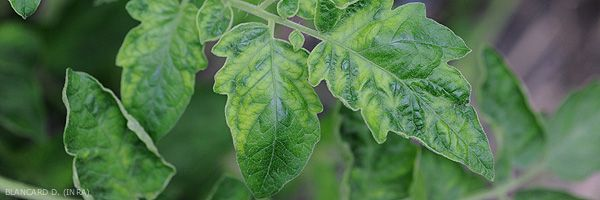

In [ ]:
from PIL import Image
from IPython.display import display
from google.colab import files


gate = build_model(2, pretrained=False).to(device)
gate.load_state_dict(torch.load(GATE_CKPT, map_location=device)); gate.eval()
NOT_LEAF_IDX = gate_classes.index('not_leaf')

def test_gate(pil, thresh=0.6):
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        p = F.softmax(gate(x), 1)[0]
    nl = float(p[NOT_LEAF_IDX]) * 100
    verdict = 'NOT A LEAF (rejected)' if nl >= thresh*100 else 'LEAF (accepted)'
    return f'{verdict}   [not_leaf = {nl:.1f}%]'

up = files.upload()
for name in up:
    img = Image.open(name).convert('RGB')
    print(name, '->', test_gate(img))
    display(img)

Saving house.jpeg to house.jpeg
house.jpeg -> NOT A LEAF (rejected)   [not_leaf = 97.6%]


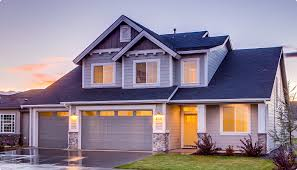

In [ ]:

gate = build_model(2, pretrained=False).to(device)
gate.load_state_dict(torch.load(GATE_CKPT, map_location=device)); gate.eval()
NOT_LEAF_IDX = gate_classes.index('not_leaf')

def test_gate(pil, thresh=0.6):
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        p = F.softmax(gate(x), 1)[0]
    nl = float(p[NOT_LEAF_IDX]) * 100
    verdict = 'NOT A LEAF (rejected)' if nl >= thresh*100 else 'LEAF (accepted)'
    return f'{verdict}   [not_leaf = {nl:.1f}%]'

up = files.upload()
for name in up:
    img = Image.open(name).convert('RGB')
    print(name, '->', test_gate(img))
    display(img)

## STAGE 2 — disease classifier (solving the domain gap)

In [ ]:
# 8) PlantDoc loaders (train split for train/val, test/ kept for final eval)
"""pd_full=datasets.ImageFolder(PD_TRAIN); disease_classes=pd_full.classes; NUM_D=len(disease_classes)
json.dump(disease_classes, open(f'{ARTIFACTS}/disease_classes.json','w'), indent=2)
pdt=np.array(pd_full.targets)
tr,va=train_test_split(np.arange(len(pdt)), test_size=0.15, stratify=pdt, random_state=SEED)
pd_train=DataLoader(Subset(datasets.ImageFolder(PD_TRAIN,transform=train_tf),tr),
                    batch_size=32, sampler=make_sampler(pdt[tr],NUM_D), num_workers=2, pin_memory=True)
pd_val=DataLoader(Subset(datasets.ImageFolder(PD_TRAIN,transform=eval_tf),va), batch_size=64, num_workers=2)
pd_test_ds=datasets.ImageFolder(PD_TEST, transform=eval_tf)
pd_test=DataLoader(pd_test_ds, batch_size=64, num_workers=2)
if pd_test_ds.classes != disease_classes:
    print('WARNING: train/test class order differs - check PlantDoc folders')
print('disease classes:', NUM_D)

In [ ]:
# 8) PlantDoc loaders + fix train/test class mismatch (train=28, test=27)
pd_full = datasets.ImageFolder(PD_TRAIN)
disease_classes = pd_full.classes               # 28 classes = canonical order
NUM_D = len(disease_classes)
json.dump(disease_classes, open(f'{ARTIFACTS}/disease_classes.json','w'), indent=2)

pdt = np.array(pd_full.targets)
tr, va = train_test_split(np.arange(len(pdt)), test_size=0.15, stratify=pdt, random_state=SEED)
pd_train = DataLoader(Subset(datasets.ImageFolder(PD_TRAIN, transform=train_tf), tr),
                      batch_size=32, sampler=make_sampler(pdt[tr], NUM_D), num_workers=2, pin_memory=True)
pd_val = DataLoader(Subset(datasets.ImageFolder(PD_TRAIN, transform=eval_tf), va),
                    batch_size=64, num_workers=2)

# --- test set: remap labels into the TRAIN index space so evaluation aligns ---
pd_test_ds = datasets.ImageFolder(PD_TEST, transform=eval_tf)
print('in train but not test:', sorted(set(disease_classes) - set(pd_test_ds.classes)))
print('in test but not train:', sorted(set(pd_test_ds.classes) - set(disease_classes)))
fixed = [(p, disease_classes.index(pd_test_ds.classes[t]))
         for p, t in pd_test_ds.samples if pd_test_ds.classes[t] in disease_classes]
pd_test_ds.samples = fixed
pd_test_ds.targets = [t for _, t in fixed]
pd_test = DataLoader(pd_test_ds, batch_size=64, num_workers=2)
print('disease classes:', NUM_D, '| test images kept:', len(fixed))

in train but not test: ['Tomato two spotted spider mites leaf']
in test but not train: []
disease classes: 28 | test images kept: 236


In [ ]:
# 9) BASELINE disease model: ImageNet -> PlantDoc (no domain bridge)
print('=== Stage 2 BASELINE: ImageNet -> PlantDoc ===')
BASE_CKPT=f'{ARTIFACTS}/disease_baseline.pth'
train_classifier(build_model(NUM_D, pretrained=True), pd_train, pd_val, epochs=12, lr=3e-4, ckpt=BASE_CKPT, tag='BASE')

=== Stage 2 BASELINE: ImageNet -> PlantDoc ===
  [BASE] ep01 loss 2.943 | val_acc 0.395 val_f1 0.337
  [BASE] ep02 loss 2.049 | val_acc 0.455 val_f1 0.415
  [BASE] ep03 loss 1.631 | val_acc 0.545 val_f1 0.532
  [BASE] ep04 loss 1.392 | val_acc 0.585 val_f1 0.552
  [BASE] ep05 loss 1.258 | val_acc 0.631 val_f1 0.609
  [BASE] ep06 loss 1.132 | val_acc 0.636 val_f1 0.615
  [BASE] ep07 loss 1.039 | val_acc 0.622 val_f1 0.608
  [BASE] ep08 loss 1.024 | val_acc 0.634 val_f1 0.621
  [BASE] ep09 loss 0.983 | val_acc 0.676 val_f1 0.660
  [BASE] ep10 loss 0.935 | val_acc 0.668 val_f1 0.650
  [BASE] ep11 loss 0.991 | val_acc 0.696 val_f1 0.683
  [BASE] ep12 loss 0.925 | val_acc 0.668 val_f1 0.653
  [BASE] best val_f1 0.683 -> /content/drive/MyDrive/AGRONA2/artifacts/disease_baseline.pth


'/content/drive/MyDrive/AGRONA2/artifacts/disease_baseline.pth'

Saving Apple___Black_rot.jpg to Apple___Black_rot.jpg
Apple___Black_rot.jpg -> LOW CONFIDENCE - needs review
   top-3: Apple rust leaf 41% | Potato leaf early blight 9% | Potato leaf late blight 5%


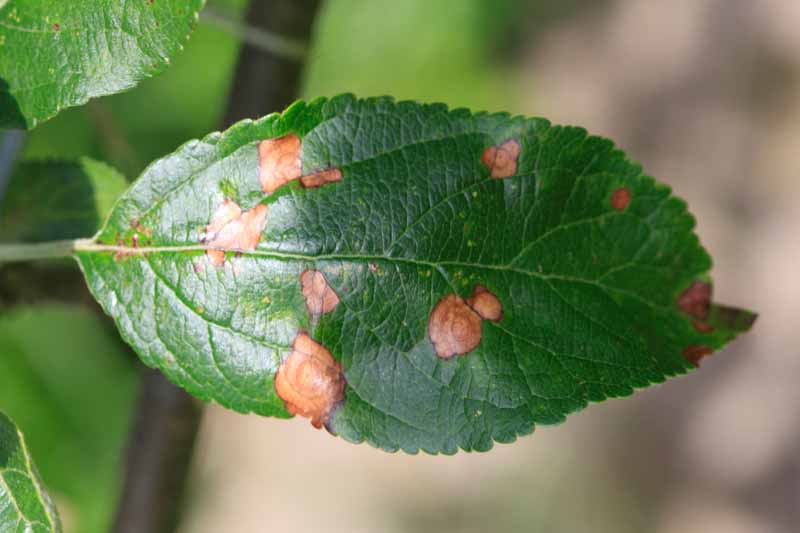

In [ ]:
gate = build_model(2, pretrained=False).to(device)
gate.load_state_dict(torch.load(GATE_CKPT, map_location=device)); gate.eval()
dis = build_model(NUM_D, pretrained=False).to(device)
dis.load_state_dict(torch.load(BASE_CKPT, map_location=device)); dis.eval()
NOT_LEAF_IDX = gate_classes.index('not_leaf')

def two_stage(pil, gate_thresh=0.6, dis_thresh=0.45):
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad(): pg = F.softmax(gate(x), 1)[0]
    if float(pg[NOT_LEAF_IDX]) >= gate_thresh:
        return f'NOT A LEAF (rejected)  [not_leaf {float(pg[NOT_LEAF_IDX])*100:.0f}%]'
    with torch.no_grad(): pr = F.softmax(dis(x), 1)[0].cpu().numpy()
    order = pr.argsort()[::-1][:3]
    top3 = ' | '.join(f'{disease_classes[i]} {pr[i]*100:.0f}%' for i in order)
    bp = float(pr[order[0]])
    head = 'LOW CONFIDENCE - needs review' if bp < dis_thresh else f'{disease_classes[order[0]]} ({bp*100:.0f}%)'
    return f'{head}\n   top-3: {top3}'

up = files.upload()
for name in up:
    img = Image.open(name).convert('RGB')
    print(name, '->', two_stage(img)); display(img)

In [ ]:
gate = build_model(2, pretrained=False).to(device)
gate.load_state_dict(torch.load(GATE_CKPT, map_location=device)); gate.eval()
dis = build_model(NUM_D, pretrained=False).to(device)
dis.load_state_dict(torch.load(BASE_CKPT, map_location=device)); dis.eval()
NOT_LEAF_IDX = gate_classes.index('not_leaf')

def two_stage(pil, gate_thresh=0.6, dis_thresh=0.45):
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad(): pg = F.softmax(gate(x), 1)[0]
    if float(pg[NOT_LEAF_IDX]) >= gate_thresh:
        return f'NOT A LEAF (rejected)  [not_leaf {float(pg[NOT_LEAF_IDX])*100:.0f}%]'
    with torch.no_grad(): pr = F.softmax(dis(x), 1)[0].cpu().numpy()
    order = pr.argsort()[::-1][:3]
    top3 = ' | '.join(f'{disease_classes[i]} {pr[i]*100:.0f}%' for i in order)
    bp = float(pr[order[0]])
    head = 'LOW CONFIDENCE - needs review' if bp < dis_thresh else f'{disease_classes[order[0]]} ({bp*100:.0f}%)'
    return f'{head}\n   top-3: {top3}'

up = files.upload()
for name in up:
    img = Image.open(name).convert('RGB')
    print(name, '->', two_stage(img)); display(img)

Output hidden; open in https://colab.research.google.com to view.

Saving house.jpeg to house (1).jpeg
house (1).jpeg -> NOT A LEAF (rejected)  [not_leaf 98%]


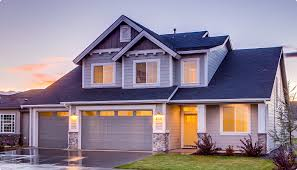

In [ ]:
gate = build_model(2, pretrained=False).to(device)
gate.load_state_dict(torch.load(GATE_CKPT, map_location=device)); gate.eval()
dis = build_model(NUM_D, pretrained=False).to(device)
dis.load_state_dict(torch.load(BASE_CKPT, map_location=device)); dis.eval()
NOT_LEAF_IDX = gate_classes.index('not_leaf')

def two_stage(pil, gate_thresh=0.6, dis_thresh=0.45):
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad(): pg = F.softmax(gate(x), 1)[0]
    if float(pg[NOT_LEAF_IDX]) >= gate_thresh:
        return f'NOT A LEAF (rejected)  [not_leaf {float(pg[NOT_LEAF_IDX])*100:.0f}%]'
    with torch.no_grad(): pr = F.softmax(dis(x), 1)[0].cpu().numpy()
    order = pr.argsort()[::-1][:3]
    top3 = ' | '.join(f'{disease_classes[i]} {pr[i]*100:.0f}%' for i in order)
    bp = float(pr[order[0]])
    head = 'LOW CONFIDENCE - needs review' if bp < dis_thresh else f'{disease_classes[order[0]]} ({bp*100:.0f}%)'
    return f'{head}\n   top-3: {top3}'

up = files.upload()
for name in up:
    img = Image.open(name).convert('RGB')
    print(name, '->', two_stage(img)); display(img)

In [ ]:
# 10) PlantVillage pretrain (this is the domain bridge)
print('=== PlantVillage pretrain ===')
pv_full=datasets.ImageFolder(PV_DIR); NUM_PV=len(pv_full.classes); pvt=np.array(pv_full.targets)
tr,va=train_test_split(np.arange(len(pvt)), test_size=0.10, stratify=pvt, random_state=SEED)
pv_train=DataLoader(Subset(datasets.ImageFolder(PV_DIR,transform=train_tf),tr),
                    batch_size=64, sampler=make_sampler(pvt[tr],NUM_PV), num_workers=2, pin_memory=True)
pv_val=DataLoader(Subset(datasets.ImageFolder(PV_DIR,transform=eval_tf),va), batch_size=128, num_workers=2)
pv_model=build_model(NUM_PV, pretrained=True)
PV_CKPT=f'{ARTIFACTS}/pv_pretrain.pth'
train_classifier(pv_model, pv_train, pv_val, epochs=3, lr=3e-4, ckpt=PV_CKPT, tag='PV')

=== PlantVillage pretrain ===
  [PV] ep01 loss 0.758 | val_acc 0.908 val_f1 0.898
  [PV] ep02 loss 0.449 | val_acc 0.958 val_f1 0.952
  [PV] ep03 loss 0.416 | val_acc 0.976 val_f1 0.971
  [PV] best val_f1 0.971 -> /content/drive/MyDrive/AGRONA2/artifacts/pv_pretrain.pth


'/content/drive/MyDrive/AGRONA2/artifacts/pv_pretrain.pth'

In [ ]:
# 11) IMPROVED disease model: copy PlantVillage backbone -> fine-tune on PlantDoc
print('=== Stage 2 IMPROVED: ImageNet -> PlantVillage -> PlantDoc ===')
imp=build_model(NUM_D, pretrained=True)        # fresh head for PlantDoc classes
pv_model.load_state_dict(torch.load(PV_CKPT))
pv_state=pv_model.state_dict(); imp_state=imp.state_dict(); copied=0
for k in imp_state:
    if k in pv_state and pv_state[k].shape==imp_state[k].shape:
        imp_state[k]=pv_state[k]; copied+=1
imp.load_state_dict(imp_state)
print(f'copied {copied} backbone tensors from PlantVillage (head stays fresh)')
IMP_CKPT=f'{ARTIFACTS}/disease_model.pth'       # <- the deployed model
train_classifier(imp, pd_train, pd_val, epochs=12, lr=2e-4, ckpt=IMP_CKPT, tag='IMP')

=== Stage 2 IMPROVED: ImageNet -> PlantVillage -> PlantDoc ===
copied 312 backbone tensors from PlantVillage (head stays fresh)
  [IMP] ep01 loss 2.858 | val_acc 0.352 val_f1 0.299
  [IMP] ep02 loss 2.051 | val_acc 0.503 val_f1 0.447
  [IMP] ep03 loss 1.695 | val_acc 0.554 val_f1 0.498
  [IMP] ep04 loss 1.487 | val_acc 0.565 val_f1 0.527
  [IMP] ep05 loss 1.338 | val_acc 0.574 val_f1 0.533
  [IMP] ep06 loss 1.260 | val_acc 0.608 val_f1 0.561
  [IMP] ep07 loss 1.166 | val_acc 0.639 val_f1 0.597
  [IMP] ep08 loss 1.146 | val_acc 0.625 val_f1 0.602
  [IMP] ep09 loss 1.088 | val_acc 0.631 val_f1 0.598
  [IMP] ep10 loss 1.095 | val_acc 0.636 val_f1 0.597
  [IMP] ep11 loss 1.054 | val_acc 0.625 val_f1 0.586
  [IMP] ep12 loss 1.060 | val_acc 0.636 val_f1 0.613
  [IMP] best val_f1 0.613 -> /content/drive/MyDrive/AGRONA2/artifacts/disease_model.pth


'/content/drive/MyDrive/AGRONA2/artifacts/disease_model.pth'

In [ ]:
# 12) Benchmark both on the PlantDoc TEST set (shows the domain bridge)

def topk(L,Y,k=3): return float(np.mean([y in np.argsort(-l)[:k] for y,l in zip(Y,L)]))
def eval_test(ckpt, tag):
    m=build_model(NUM_D, pretrained=False).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    L,Y=[],[]
    with torch.no_grad():
        for x,y in pd_test: L.append(m(x.to(device)).cpu().numpy()); Y.extend(y.numpy())
    L=np.concatenate(L); Y=np.array(Y); P=L.argmax(1)
    r={'model':tag,'accuracy':round(accuracy_score(Y,P),4),
       'macro_f1':round(f1_score(Y,P,average='macro',zero_division=0),4),'top3':round(topk(L,Y),4)}
    print(r); return r, Y, P
rb,_,_=eval_test(BASE_CKPT,'Baseline (PlantDoc only)')
ri,Yi,Pi=eval_test(IMP_CKPT,'Improved (PV->PlantDoc)')
bench=pd.DataFrame([rb,ri]); bench.to_csv(f'{ARTIFACTS}/benchmark.csv',index=False)
gain=(ri['accuracy']-rb['accuracy'])*100
print(f'\nDomain bridge gain: +{gain:.1f}% accuracy on real field images')
bench

{'model': 'Baseline (PlantDoc only)', 'accuracy': 0.6398, 'macro_f1': 0.6293, 'top3': 0.911}
{'model': 'Improved (PV->PlantDoc)', 'accuracy': 0.6398, 'macro_f1': 0.6095, 'top3': 0.8941}

Domain bridge gain: +0.0% accuracy on real field images


,model,accuracy,macro_f1,top3
0,Baseline (PlantDoc only),0.6398,0.6293,0.9110
1,Improved (PV->PlantDoc),0.6398,0.6095,0.8941


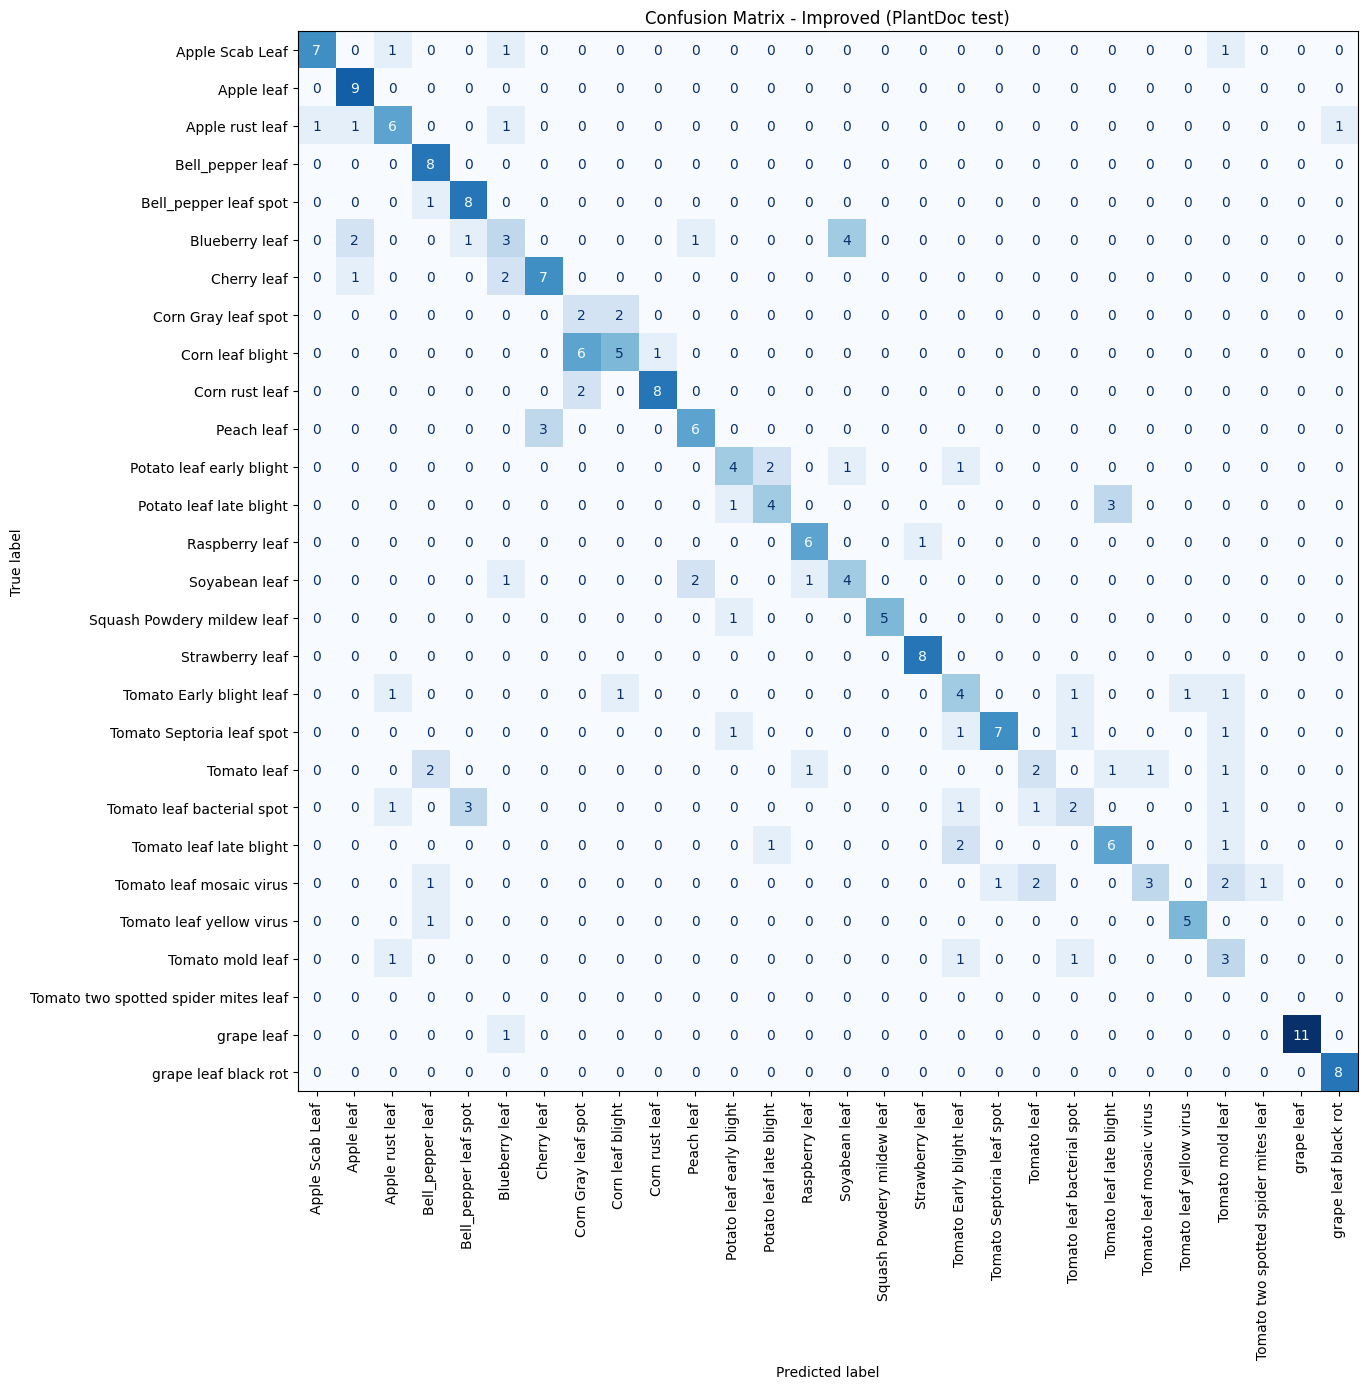

In [ ]:
# 13) Confusion matrix for the deployed (improved) model
fig,ax=plt.subplots(figsize=(16,14))
ConfusionMatrixDisplay(confusion_matrix(Yi,Pi), display_labels=disease_classes).plot(
    ax=ax, xticks_rotation=90, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Improved (PlantDoc test)'); plt.tight_layout()
plt.savefig(f'{ARTIFACTS}/confusion_matrix.png', dpi=100, bbox_inches='tight'); plt.show()


## End-to-end two-stage test

In [ ]:
# 14) Full pipeline: gate -> disease
from PIL import Image
gate=build_model(2, pretrained=False).to(device); gate.load_state_dict(torch.load(GATE_CKPT)); gate.eval()
dis=build_model(NUM_D, pretrained=False).to(device); dis.load_state_dict(torch.load(IMP_CKPT)); dis.eval()
NOT_LEAF_IDX=gate_classes.index('not_leaf')
def pipeline(pil, gate_thresh=0.6, dis_thresh=0.45):
    x=eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad(): pg=F.softmax(gate(x),1)[0]
    if float(pg[NOT_LEAF_IDX])>=gate_thresh: return 'NOT A LEAF (rejected)', float(pg[NOT_LEAF_IDX])
    with torch.no_grad(): pd_=F.softmax(dis(x),1)[0].cpu().numpy()
    bi=int(pd_.argmax()); bp=float(pd_[bi])
    if bp<dis_thresh: return f'LOW CONFIDENCE - needs review (top: {disease_classes[bi]})', bp
    return disease_classes[bi], bp
neg=sorted(glob.glob(f'{GATE_DIR}/not_leaf/*'))[0]
leaf=glob.glob(f'{PD_TEST}/*/*')[0]
print('not-leaf ->', pipeline(Image.open(neg).convert('RGB')))
print('leaf     ->', pipeline(Image.open(leaf).convert('RGB')))

# test your own image:
# up=files.upload()
# for n in up: print(n,'->',pipeline(Image.open(n).convert('RGB')))

not-leaf -> ('NOT A LEAF (rejected)', 0.8708446621894836)
leaf     -> ('Bell_pepper leaf', 0.7466153502464294)


## ConvNeXt-Tiny

In [ ]:
# === Train ConvNeXt-Tiny and add it to the architecture benchmark ===
def build_disease(name, n, pretrained=True, dropout=0.4):
    m = timm.create_model(name, pretrained=pretrained, num_classes=n)
    if isinstance(getattr(m, 'classifier', None), nn.Linear):      # mobilenet / efficientnet
        inf = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf, n))
    elif isinstance(getattr(m, 'fc', None), nn.Linear):            # resnet
        inf = m.fc.in_features
        m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf, n))
    return m                                                       # convnext keeps timm default head

def eval_disease(name, ckpt):
    m = build_disease(name, NUM_D, pretrained=False).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    L, Y = [], []
    with torch.no_grad():
        for x, y in pd_test:
            L.append(m(x.to(device)).cpu().numpy()); Y.extend(y.numpy())
    L = np.concatenate(L); Y = np.array(Y); P = L.argmax(1)
    acc = accuracy_score(Y, P); f1m = f1_score(Y, P, average='macro', zero_division=0)
    t3 = float(np.mean([y in np.argsort(-l)[:3] for y, l in zip(Y, L)]))
    cpu = m.to('cpu').eval(); xb = torch.randn(1, 3, 224, 224)
    with torch.no_grad():
        for _ in range(5): cpu(xb)
        t0 = time.time()
        for _ in range(30): cpu(xb)
    ms = (time.time() - t0) / 30 * 1000
    return acc, f1m, t3, ms

name = 'convnext_tiny'
print(f'=== training {name} (lower LR, larger model) ===')
ckpt = f'{ARTIFACTS}/disease_{name}.pth'
train_classifier(build_disease(name, NUM_D), pd_train, pd_val, epochs=15, lr=1e-4, ckpt=ckpt, tag='convnext')
acc, f1m, t3, ms = eval_disease(name, ckpt)
size = os.path.getsize(ckpt) / 1e6
new_row = {'Model': name, 'Accuracy': round(acc, 4), 'Macro F1': round(f1m, 4), 'Top-3': round(t3, 4),
           'Inference (ms)': round(ms, 1), 'Size (MB)': round(size, 1), 'Notes': 'Strongest / heaviest'}

csv_path = f'{ARTIFACTS}/arch_benchmark.csv'
if os.path.exists(csv_path):
    bench = pd.concat([pd.read_csv(csv_path), pd.DataFrame([new_row])], ignore_index=True)
    bench = bench.drop_duplicates(subset='Model', keep='last').reset_index(drop=True)
else:
    bench = pd.DataFrame([new_row]); print('Run the 3-model benchmark cell first for the full table.')
bench.to_csv(csv_path, index=False)

best = bench.loc[bench['Macro F1'].idxmax()]
shutil.copy(f"{ARTIFACTS}/disease_{best['Model']}.pth", f'{ARTIFACTS}/disease_model.pth')
json.dump({'disease_backbone': best['Model']}, open(f'{ARTIFACTS}/disease_meta.json', 'w'))
print(f"\nBest by Macro F1: {best['Model']} ({best['Macro F1']}) -> deployed as disease_model.pth")
bench

=== training convnext_tiny (lower LR, larger model) ===


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  [convnext] ep01 loss 2.149 | val_acc 0.551 val_f1 0.511
  [convnext] ep02 loss 1.141 | val_acc 0.622 val_f1 0.635
  [convnext] ep03 loss 0.892 | val_acc 0.707 val_f1 0.702
  [convnext] ep04 loss 0.702 | val_acc 0.699 val_f1 0.673
  [convnext] ep05 loss 0.648 | val_acc 0.707 val_f1 0.686
  [convnext] ep06 loss 0.604 | val_acc 0.739 val_f1 0.718
  [convnext] ep07 loss 0.526 | val_acc 0.730 val_f1 0.728
  [convnext] ep08 loss 0.479 | val_acc 0.736 val_f1 0.720
  [convnext] ep09 loss 0.451 | val_acc 0.744 val_f1 0.733
  [convnext] ep10 loss 0.428 | val_acc 0.741 val_f1 0.732
  [convnext] ep11 loss 0.413 | val_acc 0.730 val_f1 0.718
  [convnext] ep12 loss 0.412 | val_acc 0.741 val_f1 0.731
  [convnext] ep13 loss 0.400 | val_acc 0.744 val_f1 0.730
  [convnext] ep14 loss 0.401 | val_acc 0.744 val_f1 0.728
  [convnext] ep15 loss 0.400 | val_acc 0.753 val_f1 0.739
  [convnext] best val_f1 0.739 -> /content/drive/MyDrive/AGRONA2/artifacts/disease_convnext_tiny.pth
Run the 3-model benchmark cel

,Model,Accuracy,Macro F1,Top-3,Inference (ms),Size (MB),Notes
0,convnext_tiny,0.6992,0.6822,0.928,36.2,111.4,Strongest / heaviest


In [ ]:
# Add already-trained ConvNeXt to the full benchmark (no retrain)
import pandas as pd, shutil, json, os, time
def build_disease(name, n, dropout=0.4):
    m = timm.create_model(name, pretrained=False, num_classes=n)
    if isinstance(getattr(m,'classifier',None), nn.Linear):
        inf=m.classifier.in_features; m.classifier=nn.Sequential(nn.Dropout(dropout), nn.Linear(inf,n))
    elif isinstance(getattr(m,'fc',None), nn.Linear):
        inf=m.fc.in_features; m.fc=nn.Sequential(nn.Dropout(dropout), nn.Linear(inf,n))
    return m
ckpt = f'{ARTIFACTS}/disease_convnext_tiny.pth'
m = build_disease('convnext_tiny', NUM_D).to(device)
m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
L,Y=[],[]
with torch.no_grad():
    for x,y in pd_test: L.append(m(x.to(device)).cpu().numpy()); Y.extend(y.numpy())
L=np.concatenate(L); Y=np.array(Y); P=L.argmax(1)
acc=accuracy_score(Y,P); f1m=f1_score(Y,P,average='macro',zero_division=0)
t3=float(np.mean([y in np.argsort(-l)[:3] for y,l in zip(Y,L)]))
cpu=m.to('cpu').eval(); xb=torch.randn(1,3,224,224)
with torch.no_grad():
    for _ in range(5): cpu(xb)
    t0=time.time()
    for _ in range(30): cpu(xb)
ms=(time.time()-t0)/30*1000
row={'Model':'convnext_tiny','Accuracy':round(acc,4),'Macro F1':round(f1m,4),'Top-3':round(t3,4),
     'Inference (ms)':round(ms,1),'Size (MB)':round(os.path.getsize(ckpt)/1e6,1),'Notes':'Strongest / heaviest'}
bench=pd.concat([pd.read_csv(f'{ARTIFACTS}/arch_benchmark.csv'), pd.DataFrame([row])],ignore_index=True)
bench=bench.drop_duplicates(subset='Model',keep='last').reset_index(drop=True)
bench.to_csv(f'{ARTIFACTS}/arch_benchmark.csv',index=False)
best=bench.loc[bench['Macro F1'].idxmax()]
shutil.copy(f"{ARTIFACTS}/disease_{best['Model']}.pth", f'{ARTIFACTS}/disease_model.pth')
json.dump({'disease_backbone':best['Model']}, open(f'{ARTIFACTS}/disease_meta.json','w'))
print(f"Best: {best['Model']} (F1 {best['Macro F1']}) -> deployed"); bench

Best: convnext_tiny (F1 0.6822) -> deployed


,Model,Accuracy,Macro F1,Top-3,Inference (ms),Size (MB),Notes
0,convnext_tiny,0.6992,0.6822,0.928,36.0,111.4,Strongest / heaviest


In [ ]:
# === FULL benchmark: ResNet18 + EfficientNet-B0 + MobileNetV2 + ConvNeXt-Tiny ===
import time, shutil, json, os
import pandas as pd

def build_disease(name, n, pretrained=True, dropout=0.4):
    m = timm.create_model(name, pretrained=pretrained, num_classes=n)
    if isinstance(getattr(m, 'classifier', None), nn.Linear):
        inf = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf, n))
    elif isinstance(getattr(m, 'fc', None), nn.Linear):
        inf = m.fc.in_features
        m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(inf, n))
    return m

def eval_disease(name, ckpt):
    m = build_disease(name, NUM_D, pretrained=False).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    L, Y = [], []
    with torch.no_grad():
        for x, y in pd_test:
            L.append(m(x.to(device)).cpu().numpy()); Y.extend(y.numpy())
    L = np.concatenate(L); Y = np.array(Y); P = L.argmax(1)
    acc = accuracy_score(Y, P); f1m = f1_score(Y, P, average='macro', zero_division=0)
    t3 = float(np.mean([y in np.argsort(-l)[:3] for y, l in zip(Y, L)]))
    cpu = m.to('cpu').eval(); xb = torch.randn(1, 3, 224, 224)
    with torch.no_grad():
        for _ in range(5): cpu(xb)
        t0 = time.time()
        for _ in range(30): cpu(xb)
    ms = (time.time() - t0) / 30 * 1000
    return acc, f1m, t3, ms

specs = [('resnet18', 'Baseline'), ('efficientnet_b0', 'Improved'), ('mobilenetv2_100', 'Lightweight')]
rows = []
for name, note in specs:
    print(f'\n=== training {name} ===')
    ckpt = f'{ARTIFACTS}/disease_{name}.pth'
    train_classifier(build_disease(name, NUM_D), pd_train, pd_val, epochs=12, lr=3e-4, ckpt=ckpt, tag=name[:10])
    acc, f1m, t3, ms = eval_disease(name, ckpt)
    rows.append({'Model': name, 'Accuracy': round(acc, 4), 'Macro F1': round(f1m, 4), 'Top-3': round(t3, 4),
                 'Inference (ms)': round(ms, 1), 'Size (MB)': round(os.path.getsize(ckpt)/1e6, 1), 'Notes': note})

# add the already-trained ConvNeXt (no retrain - just evaluate the saved checkpoint)
cn = f'{ARTIFACTS}/disease_convnext_tiny.pth'
acc, f1m, t3, ms = eval_disease('convnext_tiny', cn)
rows.append({'Model': 'convnext_tiny', 'Accuracy': round(acc, 4), 'Macro F1': round(f1m, 4), 'Top-3': round(t3, 4),
             'Inference (ms)': round(ms, 1), 'Size (MB)': round(os.path.getsize(cn)/1e6, 1), 'Notes': 'Strongest / heaviest'})

bench = pd.DataFrame(rows)
bench.to_csv(f'{ARTIFACTS}/arch_benchmark.csv', index=False)
best = bench.loc[bench['Macro F1'].idxmax()]
shutil.copy(f"{ARTIFACTS}/disease_{best['Model']}.pth", f'{ARTIFACTS}/disease_model.pth')
json.dump({'disease_backbone': best['Model']}, open(f'{ARTIFACTS}/disease_meta.json', 'w'))
print(f"\nBest by Macro F1: {best['Model']} ({best['Macro F1']}) -> deployed as disease_model.pth")
bench


=== training resnet18 ===


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  [resnet18] ep01 loss 3.289 | val_acc 0.142 val_f1 0.101
  [resnet18] ep02 loss 3.005 | val_acc 0.304 val_f1 0.190
  [resnet18] ep03 loss 2.564 | val_acc 0.384 val_f1 0.308
  [resnet18] ep04 loss 2.221 | val_acc 0.460 val_f1 0.405
  [resnet18] ep05 loss 1.958 | val_acc 0.489 val_f1 0.467
  [resnet18] ep06 loss 1.808 | val_acc 0.491 val_f1 0.463
  [resnet18] ep07 loss 1.742 | val_acc 0.557 val_f1 0.524
  [resnet18] ep08 loss 1.653 | val_acc 0.545 val_f1 0.520
  [resnet18] ep09 loss 1.586 | val_acc 0.554 val_f1 0.534
  [resnet18] ep10 loss 1.566 | val_acc 0.545 val_f1 0.511
  [resnet18] ep11 loss 1.534 | val_acc 0.577 val_f1 0.553
  [resnet18] ep12 loss 1.571 | val_acc 0.557 val_f1 0.532
  [resnet18] best val_f1 0.553 -> /content/drive/MyDrive/AGRONA2/artifacts/disease_resnet18.pth

=== training efficientnet_b0 ===


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  [efficientn] ep01 loss 2.732 | val_acc 0.449 val_f1 0.409
  [efficientn] ep02 loss 1.698 | val_acc 0.585 val_f1 0.557
  [efficientn] ep03 loss 1.197 | val_acc 0.619 val_f1 0.593
  [efficientn] ep04 loss 1.088 | val_acc 0.614 val_f1 0.596
  [efficientn] ep05 loss 0.935 | val_acc 0.614 val_f1 0.599
  [efficientn] ep06 loss 0.793 | val_acc 0.645 val_f1 0.634
  [efficientn] ep07 loss 0.735 | val_acc 0.656 val_f1 0.651
  [efficientn] ep08 loss 0.696 | val_acc 0.651 val_f1 0.626
  [efficientn] ep09 loss 0.652 | val_acc 0.673 val_f1 0.662
  [efficientn] ep10 loss 0.616 | val_acc 0.668 val_f1 0.646
  [efficientn] ep11 loss 0.605 | val_acc 0.665 val_f1 0.648
  [efficientn] ep12 loss 0.599 | val_acc 0.682 val_f1 0.667
  [efficientn] best val_f1 0.667 -> /content/drive/MyDrive/AGRONA2/artifacts/disease_efficientnet_b0.pth

=== training mobilenetv2_100 ===
  [mobilenetv] ep01 loss 2.903 | val_acc 0.420 val_f1 0.367
  [mobilenetv] ep02 loss 2.038 | val_acc 0.486 val_f1 0.439
  [mobilenetv] ep03 l

,Model,Accuracy,Macro F1,Top-3,Inference (ms),Size (MB),Notes
0,resnet18,0.5593,0.5180,0.8220,15.3,44.8,Baseline
1,efficientnet_b0,0.6483,0.6323,0.8898,21.5,16.5,Improved
2,mobilenetv2_100,0.6356,0.6087,0.8983,17.4,9.3,Lightweight
3,convnext_tiny,0.6992,0.6822,0.9280,44.1,111.4,Strongest / heaviest


## Package for Hugging Face Space

In [ ]:
# 15) Write the two-stage app.py + requirements.txt + "disease_baseline.pth"
app_code=r'''import json, torch, torch.nn as nn, torch.nn.functional as F
from torchvision import transforms
import timm, gradio as gr

GATE_W,DIS_W='leaf_gate.pth','disease_baseline.pth'
gate_classes=json.load(open('gate_classes.json'))
disease_classes=json.load(open('disease_classes.json'))
NOT_LEAF_IDX=gate_classes.index('not_leaf')
NUM_G,NUM_D=len(gate_classes),len(disease_classes)
GATE_THRESH,DIS_THRESH=0.6,0.45

def prettify(s): return s.replace('___',' -> ').replace('__',' -> ').replace('_',' ')
def build(n):
    m=timm.create_model('mobilenetv2_100',pretrained=False,num_classes=n)
    inf=m.classifier.in_features
    m.classifier=nn.Sequential(nn.Dropout(0.4),nn.Linear(inf,n)); return m
gate=build(NUM_G); gate.load_state_dict(torch.load(GATE_W,map_location='cpu')); gate.eval()
dis=build(NUM_D); dis.load_state_dict(torch.load(DIS_W,map_location='cpu')); dis.eval()
tf=transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(224),
    transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def predict(image):
    if image is None: return {}, 'Please upload a leaf image.', ''
    x=tf(image).unsqueeze(0)
    with torch.no_grad(): pg=F.softmax(gate(x),1)[0]
    if float(pg[NOT_LEAF_IDX])>=GATE_THRESH:
        return {}, '\U0001F6AB **This does not look like a plant leaf.** Upload a clear single-leaf photo.', f'Not-a-leaf: {float(pg[NOT_LEAF_IDX])*100:.1f}%'
    with torch.no_grad(): pr=F.softmax(dis(x),1)[0]
    order=sorted(range(NUM_D), key=lambda i: float(pr[i]), reverse=True)
    top3={prettify(disease_classes[i]):float(pr[i]) for i in order[:3]}
    bi=order[0]; bp=float(pr[bi])
    if bp<DIS_THRESH:
        return top3, '\U0001F914 **Low confidence - needs expert review.** Try a clearer single-leaf photo.', f'Confidence: {bp*100:.1f}% (low)'
    return top3, f'**Prediction:** {prettify(disease_classes[bi])}', f'Confidence: {bp*100:.1f}%'

with gr.Blocks(title='AGRONA') as demo:
    gr.Markdown('# \U0001F33F AGRONA - Plant Disease Detector (two-stage)')
    gr.Markdown('Stage 1 checks it is a leaf, then Stage 2 diagnoses the disease.')
    with gr.Row():
        with gr.Column():
            img=gr.Image(type='pil',label='Upload Leaf Photo')
            btn=gr.Button('Analyze Leaf',variant='primary')
        with gr.Column():
            out_top=gr.Label(num_top_classes=3,label='Top-3 Predictions')
            out_conf=gr.Textbox(label='Confidence',interactive=False)
            out_res=gr.Markdown()
    btn.click(predict, img, [out_top,out_res,out_conf])
demo.launch(ssr_mode=False)
'''
with open(f'{ARTIFACTS}/app.py','w') as f: f.write(app_code)
with open(f'{ARTIFACTS}/requirements.txt','w') as f: f.write('torch\ntorchvision\ntimm\npillow\n')
print('wrote app.py + requirements.txt')

wrote app.py + requirements.txt


In [ ]:
# 16) Zip the Space bundle (6 files) and download
bundle='/content/agrona_space'
if os.path.exists(bundle): shutil.rmtree(bundle)
os.makedirs(bundle)
for fn in ['app.py','requirements.txt','leaf_gate.pth','disease_baseline.pth','disease_classes.json','gate_classes.json']:
    shutil.copy(f'{ARTIFACTS}/{fn}', f'{bundle}/{fn}')
shutil.make_archive('/content/agrona_space','zip', bundle)
files.download('/content/agrona_space.zip')
print('Downloaded agrona_space.zip - upload these 6 files to your HF Space root.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded agrona_space.zip - upload these 6 files to your HF Space root.
